Projeto: Análise de Avaliações de Clientes com Modelo de Linguagem Natural

Integrantes:
- Mariana Okamoto - 10418069 - 10418069@mackenzista.com.br

Descrição:
Este notebook utiliza um modelo de linguagem baseado em Transformers
para realizar análises textuais em avaliações de clientes, incluindo
classificação de sentimentos, identificação de temas recorrentes
e geração de resumos automáticos.

Histórico de alterações:

- 17/05/2026 – Criação do notebook e importação dos dados
- 17/05/2026 – Implementação da análise textual com modelo de linguagem
- 19/05/2026 – Implementação da classificação de sentimentos e geração de insights

In [13]:
import transformers

In [2]:
import pandas as pd
df = pd.read_csv("dataset89coffee_tratado.csv")
df.head()

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,Espera,tamanho_texto
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,Não informado,1116
1,5,3 semanas atrás,Outro,R$ 20–40,"a comida é incrível, mas erraram no sabor da m...",5,4,4,"Nível muito alto de barulho, difícil de ouvir",Não informado,388
2,5,2 meses atrás,Outro,R$ 40–60,incrível!!!visitamos a 89 em uma sexta por vol...,5,5,5,Não informado,Não informado,1210
3,2,3 semanas atrás,Outro,R$ 40–60,"vitrine lindaaa, você olha e quer comer tudooo...",2,4,4,Nível moderado de barulho,Sem espera,265
4,5,3 meses atrás,Café da manhã,R$ 80–100,"meu lugar favorito da liba, tem muita fila mas...",5,5,5,Nível moderado de barulho,De 10 a 30 min,815


In [3]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [5]:
df['sentimento'] = df['Comentario'].apply(
    lambda x: classifier(
        str(x),
        truncation=True,
        max_length=512
    )[0]['label']
)

In [6]:
df[['Comentario', 'Nota', 'sentimento']]

,Comentario,Nota,sentimento
0,"fui hoje, domingo, por volta de 09h da manhã j...",4,1 star
1,"a comida é incrível, mas erraram no sabor da m...",5,3 stars
2,incrível!!!visitamos a 89 em uma sexta por vol...,5,5 stars
3,"vitrine lindaaa, você olha e quer comer tudooo...",2,1 star
4,"meu lugar favorito da liba, tem muita fila mas...",5,5 stars
...,...,...,...
131,uma das melhores experiências que eu já tive n...,5,5 stars
132,"verias opções de café, pães, salgados e doces,...",5,5 stars
133,"adorei este café, tem uma fila danada mas vale...",5,5 stars
134,tudo muito saboroso e bem feito. ambiente agra...,5,4 stars


In [7]:
df['sentimento'].value_counts()

,count
sentimento,
4 stars,47
5 stars,45
2 stars,18
3 stars,17
1 star,9


In [8]:
df[
    (df['Nota'] >= 4) &
    (df['sentimento'].isin(['1 star', '2 stars']))
]

,Nota,HaQuantoTempo,TipoRefeicao,Preco,Comentario,Comida,Serviço,Ambiente,Barulho,Espera,tamanho_texto,sentimento
0,4,3 semanas atrás,Café da manhã,R$ 40–60,"fui hoje, domingo, por volta de 09h da manhã j...",5,3,4,Nível moderado de barulho,Não informado,1116,1 star
21,5,um mês atrás,Café da manhã,R$ 20–40,it was crowded. probably because it's saturday...,5,5,5,Nível moderado de barulho,Sem espera,185,2 stars
45,4,5 meses atrás,Café da manhã,R$ 80–100,muito demorado a fila pra entrar aos domingos ...,5,4,5,Não informado,De 30 a 60 min,199,2 stars
46,5,Editado 3 meses atrás,Não informado,Não informado,"fui em dois dias, no sábado e domingo. os dois...",5,5,5,Não informado,Não informado,745,2 stars
52,5,6 meses atrás,Não informado,Não informado,o que falar da 89ºc?todos os finais de semana ...,5,5,5,Não informado,Não informado,336,1 star
56,4,um mês atrás,R$ 40–60,Não informado,já foi melhor... gostava muito da coxinha de s...,4,5,4,"Nível alto de barulho, mas ainda é possível co...",Não informado,246,2 stars
59,4,4 meses atrás,Não informado,Não informado,"a comida é ótima e os preços ok, mas o lugar é...",5,4,4,Não informado,Não informado,155,2 stars
61,5,3 meses atrás,Brunch,R$ 40–60,doces e salgados fantásticos.... variedades qu...,5,3,4,"Nível alto de barulho, mas ainda é possível co...",De 10 a 30 min,312,2 stars
63,4,10 meses atrás,Refeição no local,Jantar,"fomos numa segunda-feira, então filas do lado ...",4,5,5,Não informado,Não informado,600,2 stars
64,4,5 meses atrás,R$ 20–40,Não informado,a torta de frutas vermelhas é maravilhosa! inf...,3,3,4,Nível moderado de barulho,Não informado,190,1 star


In [9]:
def converter_sentimento(label):
    return int(label[0])

df['sentimento_num'] = df['sentimento'].apply(converter_sentimento)
df['diferenca'] = abs(df['Nota'] - df['sentimento_num'])
print("Diferença entre a nota e o sentimento detectado: ")
df['diferenca'].mean()

Diferença entre a nota e o sentimento detectado: 


np.float64(0.7720588235294118)

In [10]:
coerencia = (abs(df['Nota'] - df['sentimento_num']) <= 1).mean() * 100

print(f"Coerência aproximada: {coerencia:.2f}%")

Coerência aproximada: 85.29%


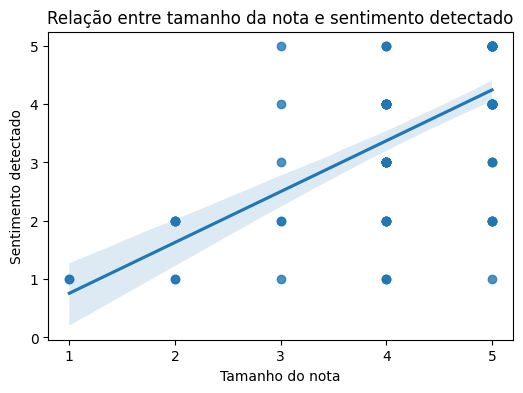

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.regplot(x='Nota', y='sentimento_num', data=df)
plt.title("Relação entre tamanho da nota e sentimento detectado")
plt.xlabel("Tamanho do nota")
plt.ylabel("Sentimento detectado")
plt.xticks(np.arange(1, 6, 1))
plt.show()

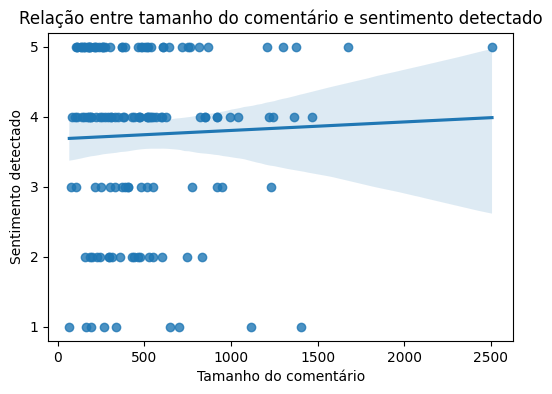

In [12]:
df['tamanho_texto'] = df['Comentario'].astype(str).apply(len)

plt.figure(figsize=(6,4))
sns.regplot(x='tamanho_texto', y='sentimento_num', data=df)
plt.title("Relação entre tamanho do comentário e sentimento detectado")
plt.xlabel("Tamanho do comentário")
plt.ylabel("Sentimento detectado")
plt.yticks(np.arange(1, 6, 1))
plt.show()